# Síndrome do Ovário Policístico (SOP/PCOS).


A Síndrome do Ovário Policístico (SOP) é um distúrbio endócrino comum que afeta o equilíbrio hormonal, ocorrendo principalmente durante a idade reprodutiva. Ela se caracteriza por um desequilíbrio nos hormônios sexuais, especialmente o aumento dos andrógenos (hormônios masculinos, como a testosterona).

Para um diagnóstico clínico, geralmente os médicos observam a presença de ao menos dois dos três critérios abaixo:

- Ciclos Menstruais Irregulares: Menstruações ausentes, pouco frequentes ou muito prolongadas.

- iperandrogenismo: Sinais de níveis elevados de hormônios masculinos, que podem se manifestar fisicamente como excesso de pelos (hirsutismo), acne grave ou queda de cabelo.

- Ovários Policísticos: A presença de pequenos folículos (bolsas com fluido) que envolvem os óvulos, visíveis em exames de imagem como o ultrassom. Apesar do nome, não são "cistos" no sentido tradicional, mas sim folículos que não se desenvolveram completamente.

# Desafio


Wolberg, W., Mangasarian, O., Street, N., & Street, W. (1993). Breast Cancer Wisconsin (Diagnostic) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C5DW2B.

https://www.kaggle.com/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos

- O Problema: Identificar a presença de SOP com base em exames hormonais e sintomas físicos.
- O Desafio: Classificar se um tumor é Maligno (M) ou Benigno (B).


- O desafio é identificar mulheres com SOP precocemente para evitar complicações como diabetes e infertilidade.

#Variáveis Chave:
Hormonais: Razão LH/FSH, Prolactina, TSH.
Físicas: Ganho de peso, crescimento de pelos (Hirsutismo), queda de cabelo, escurecimento da pele (Acantose).
Exames: Número de folículos (follicle count) e tamanho dos ovários.


# 0 - Biblioteca

In [ ]:
#%pip install kagglehub

import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import shap
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras import layers, models # type: ignore


# 1 - Carregar dados

In [2]:


# Download latest version
path = kagglehub.dataset_download("prasoonkottarathil/polycystic-ovary-syndrome-pcos")

print("Path to dataset files:", path)

Path to dataset files: /Users/diegomendes/.cache/kagglehub/datasets/prasoonkottarathil/polycystic-ovary-syndrome-pcos/versions/3


In [5]:
# ou download manual:

df = pd.read_excel("PCOS_data_without_infertility.xlsx", sheet_name="Full_new")

df.head(3)

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.30,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.92,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.27,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN


In [6]:
#Veririfcar tamanho do dataset
len(df)

541

# 1 - Tratamento de dados

In [7]:
# força tudo numérico (qualquer valor não numérico vira NaN)
df["AMH(ng/mL)"] = pd.to_numeric(df["AMH(ng/mL)"], errors="coerce")

In [8]:
# Verificar quantos valores faltantes existem na coluna "AMH(ng/mL)"
df["AMH(ng/mL)"].isna().sum()

np.int64(1)

In [9]:
# Preencher os valores faltantes com a mediana da coluna, agrupando por "PCOS (Y/N)"
df["AMH(ng/mL)"] = df.groupby("PCOS (Y/N)")["AMH(ng/mL)"]\
                     .transform(lambda x: x.fillna(x.median()))

In [10]:
# Remover colunas
df = df.drop(['Sl. No', 'Patient File No.', 'Unnamed: 44'], axis=1)

#  Tratar valores nulos
df = df.dropna() 

#  Converter tipos de dados
df = df.apply(pd.to_numeric, errors='ignore')


/var/folders/g0/_j5hgz0s1rj6p_qjq53zkgmh0000gn/T/ipykernel_96794/1013103086.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [11]:
# Limpar strings (remover espaços, pontos, etc.)
col = "II    beta-HCG(mIU/mL)"

df[col] = (
    df[col]
    .astype(str)
    .str.strip()
    .str.rstrip('.')   
)

In [12]:
# Garantir numerico
df[col] = pd.to_numeric(df[col], errors="coerce")

In [13]:
# remove pontos extras no final
def limpar_valor(x):
    if isinstance(x, str):
        return x.strip().rstrip('.')  # remove ponto no final
    return x

df = df.applymap(limpar_valor)

/var/folders/g0/_j5hgz0s1rj6p_qjq53zkgmh0000gn/T/ipykernel_96794/3072793489.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(limpar_valor)


In [14]:
df.columns

Index(['PCOS (Y/N)', ' Age (yrs)', 'Weight (Kg)', 'Height(Cm) ', 'BMI',
       'Blood Group', 'Pulse rate(bpm) ', 'RR (breaths/min)', 'Hb(g/dl)',
       'Cycle(R/I)', 'Cycle length(days)', 'Marraige Status (Yrs)',
       'Pregnant(Y/N)', 'No. of aborptions', '  I   beta-HCG(mIU/mL)',
       'II    beta-HCG(mIU/mL)', 'FSH(mIU/mL)', 'LH(mIU/mL)', 'FSH/LH',
       'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)',
       'AMH(ng/mL)', 'PRL(ng/mL)', 'Vit D3 (ng/mL)', 'PRG(ng/mL)',
       'RBS(mg/dl)', 'Weight gain(Y/N)', 'hair growth(Y/N)',
       'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)',
       'Fast food (Y/N)', 'Reg.Exercise(Y/N)', 'BP _Systolic (mmHg)',
       'BP _Diastolic (mmHg)', 'Follicle No. (L)', 'Follicle No. (R)',
       'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)', 'Endometrium (mm)'],
      dtype='object')

# 2 - Analise exploratoria

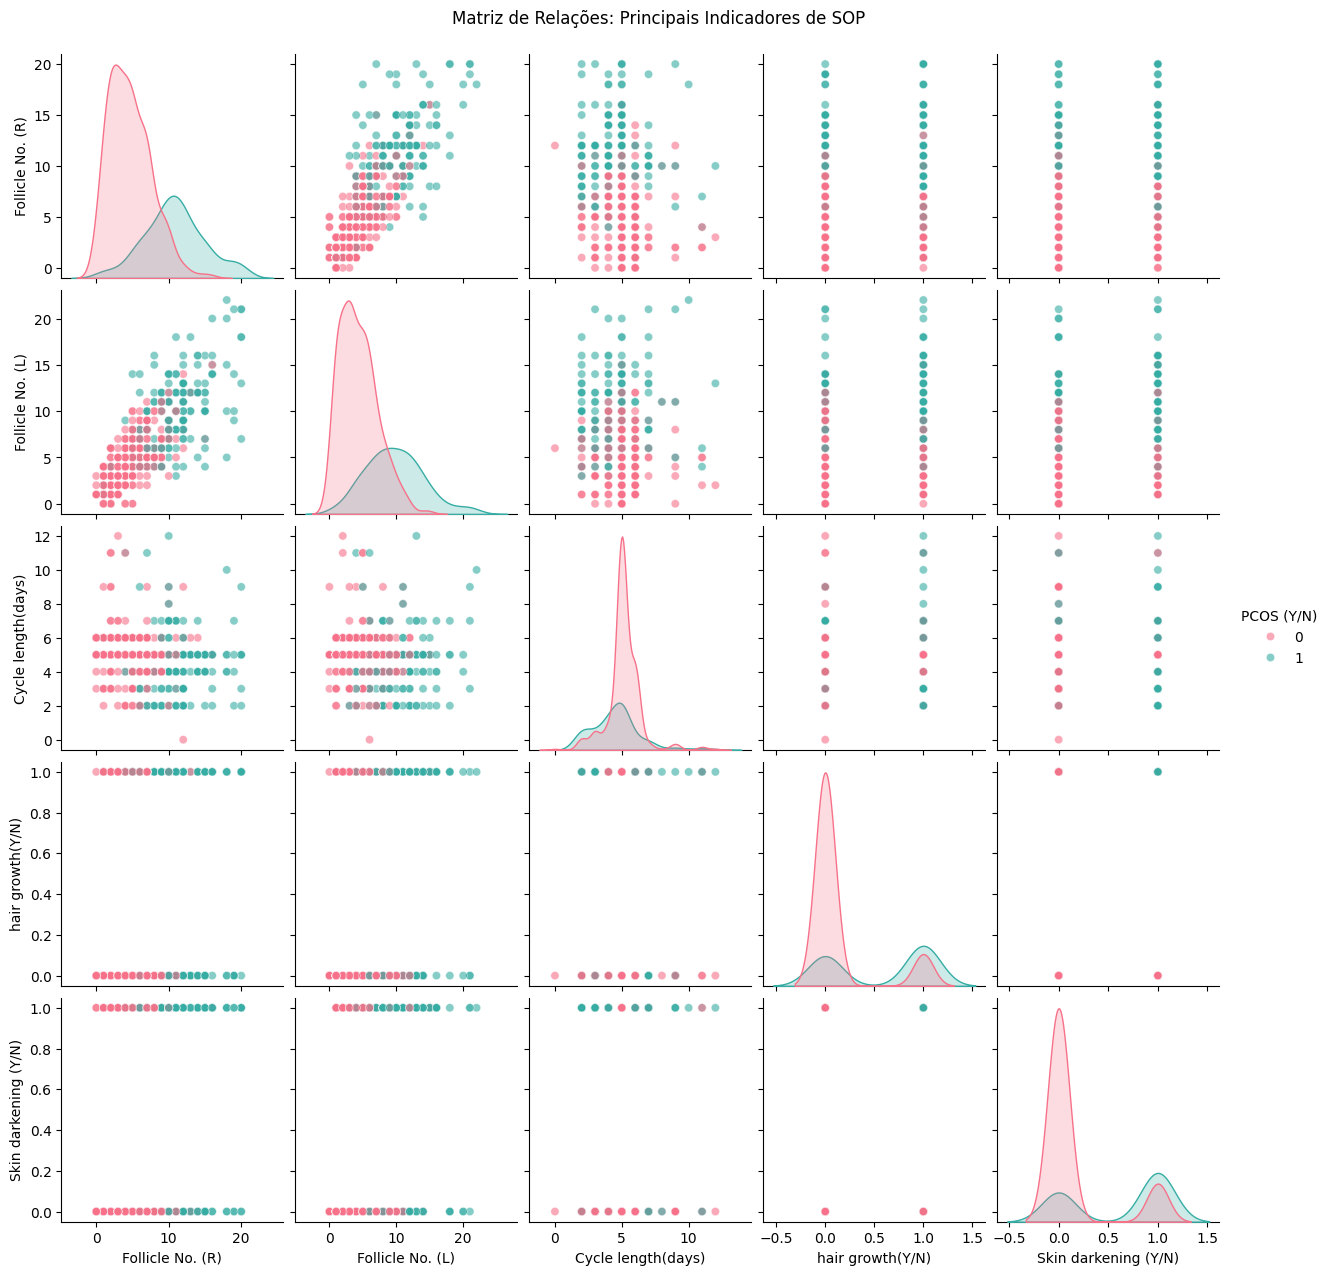

In [15]:
# Selecionando as colunas
colunas_selecionadas = [
    'Follicle No. (R)', 
    'Follicle No. (L)', 
    'Cycle length(days)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'PCOS (Y/N)'
]

# Criando o pairplot
g = sns.pairplot(
    df[colunas_selecionadas], 
    hue='PCOS (Y/N)', 
    palette='husl', 
    diag_kind='kde', 
    plot_kws={'alpha': 0.6} 
)

g.fig.suptitle("Matriz de Relações: Principais Indicadores de SOP", y=1.02)
plt.show()

 #.#.# Exploratoria insghts

1. Curvvas - Follicle No. (R) e Follicle No. (L):

As curvas rosa (Sem SOP) e verde (Com SOP) estão bem separadas.

O que isso diz: Existe um "ponto de corte" biológico muito claro. Mulheres sem SOP concentram-se em poucos folículos (pico rosa à esquerda), enquanto mulheres com SOP têm uma distribuição deslocada para a direita (muitos folículos).

Insight: Isso explica por que essas variáveis estão no topo do seu SHAP. Elas são os melhores preditores isolados.



2. Correlação Linear Quase Perfeita

O cruzamento de Follicle No. (R) vs Follicle No. (L) (o primeiro gráfico de dispersão abaixo da primeira montanha):

Os pontos formam uma linha diagonal ascendente bem nítida.

O que isso diz: Há uma correlação fortíssima entre os dois ovários. Se um ovário apresenta muitos folículos, o outro quase sempre acompanha.

Para o modelo: Isso indica multicolinearidade. Para o XGBoost não é um problema, mas para modelos lineares, poderíamos usar apenas uma dessas colunas sem perder muita informação.



3. A Variável "Ruidosa": Cycle length (days)

Coluna central:

As curvas rosa e verde estão quase sobrepostas (a montanha rosa engole a verde).

O que isso diz: O comprimento do ciclo sozinho não separa bem as classes. Existem mulheres saudáveis e com SOP com durações de ciclo parecidas.

O que mostra a necessidade de um modelo para ajudar a separar.



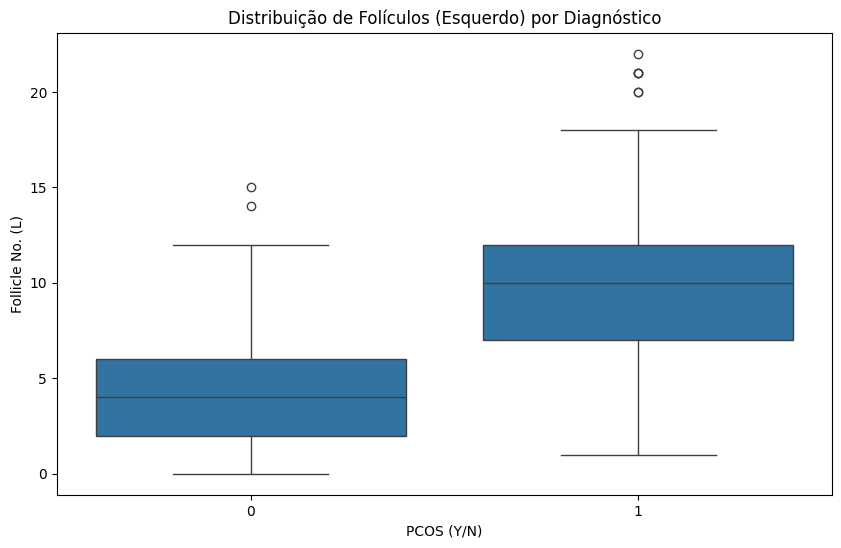

In [16]:
# Boxplot para comparar a distribuição de folículos entre os grupos
plt.figure(figsize=(10,6))
sns.boxplot(x='PCOS (Y/N)', y='Follicle No. (L)', data=df)
plt.title('Distribuição de Folículos (Esquerdo) por Diagnóstico')
plt.show()

In [17]:
# Preparação para Modelagem
X = df.drop('PCOS (Y/N)', axis=1)
y = df['PCOS (Y/N)'] # Variável alvo

# Divisão 80/20 com estratificação
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Normalização
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Regressão Logística


In [22]:

# Teste do modelo simples para comparação:
lr = LogisticRegression()
lr.fit(X_train_scaled, y_train)
print("Regressão Logística:\n", classification_report(y_test, lr.predict(X_test_scaled)))

Regressão Logística:
               precision    recall  f1-score   support

           0       0.91      0.84      0.87        73
           1       0.71      0.83      0.76        35

    accuracy                           0.83       108
   macro avg       0.81      0.83      0.82       108
weighted avg       0.84      0.83      0.84       108



/Users/diegomendes/Documents/1-Desenvolvimento/.venv_build/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/diegomendes/Documents/1-Desenvolvimento/.venv_build/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/diegomendes/Documents/1-Desenvolvimento/.venv_build/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/diegomendes/Documents/1-Desenvolvimento/.venv_build/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/diegomendes/Documents/1-Desenvolvimento/.venv_build/lib/python3.9/site-p

# XGBoost

In [18]:

# XGBoost é um modelo de árvore de decisão em ensemble, que geralmente tem melhor performance em dados tabulares e lida bem com relações não lineares e interações entre variáveis.
xgb = XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
xgb.fit(X_train, y_train) # XGBoost lida bem com dados não escalonados
print("XGBoost:\n", classification_report(y_test, xgb.predict(X_test)))

XGBoost:
               precision    recall  f1-score   support

           0       0.91      0.93      0.92        73
           1       0.85      0.80      0.82        35

    accuracy                           0.89       108
   macro avg       0.88      0.87      0.87       108
weighted avg       0.89      0.89      0.89       108



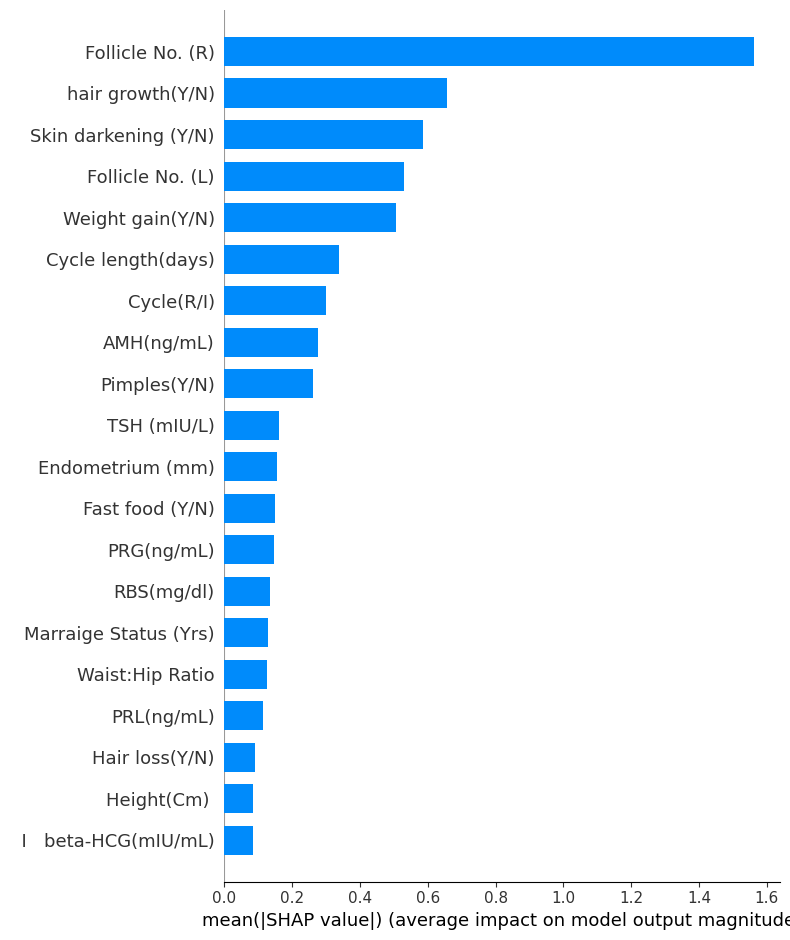

In [19]:
# importancia das features
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test, plot_type="bar")


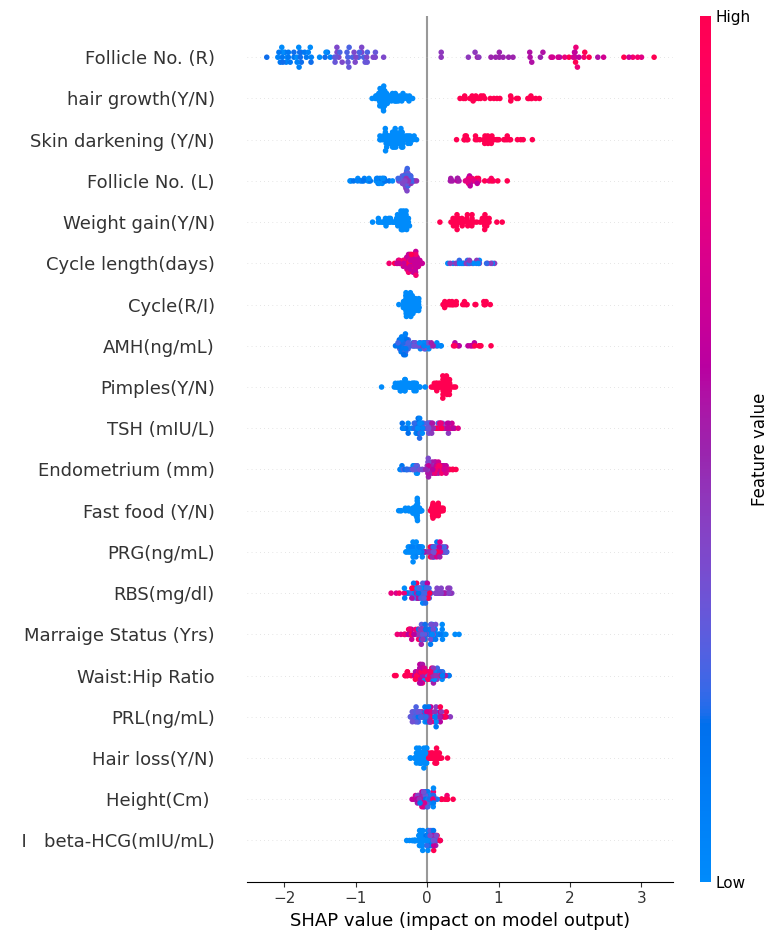

In [20]:
# SHAP
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Gráfico de resumo
shap.summary_plot(shap_values, X_test)

/Users/diegomendes/Documents/1-Desenvolvimento/.venv_build/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/diegomendes/Documents/1-Desenvolvimento/.venv_build/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/diegomendes/Documents/1-Desenvolvimento/.venv_build/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


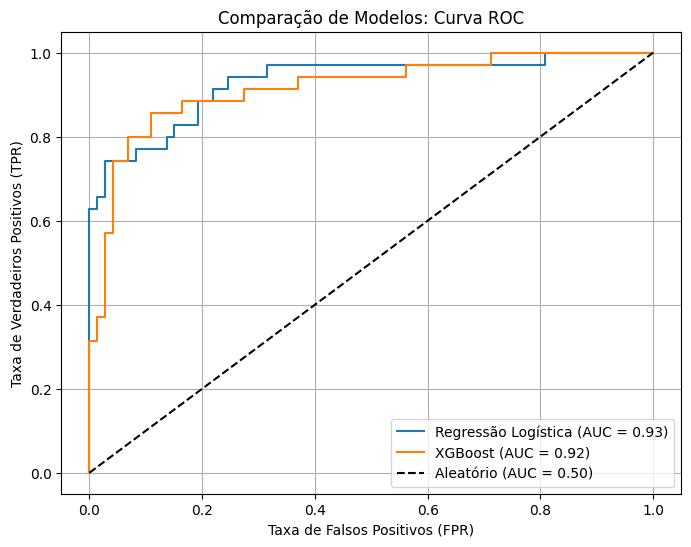

In [23]:


# 1. Obter as probabilidades
prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
prob_xgb = xgb.predict_proba(X_test)[:, 1]

# 2. Calcular os pontos da curva
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, prob_xgb)

# 3. Plotar o gráfico
plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {roc_auc_score(y_test, prob_lr):.2f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_score(y_test, prob_xgb):.2f})')

# Linha de base (chute aleatório)
plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.50)')

plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Comparação de Modelos: Curva ROC')
plt.legend()
plt.grid(True)
plt.show()

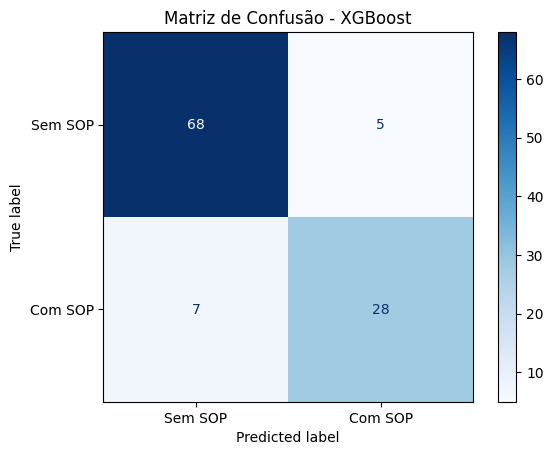

In [24]:
# Matriz de Confusão - XGBoost
cm = confusion_matrix(y_test, xgb.predict(X_test))
cmd = ConfusionMatrixDisplay(cm, display_labels=['Sem SOP', 'Com SOP'])
cmd.plot(cmap='Blues')
plt.title('Matriz de Confusão - XGBoost')
plt.show()

In [ ]:
#EXTRA
# Função de predição para nova paciente
def predizer_risco_paciente(dados_nova_paciente):
    # Transforma os dados de entrada no formato do modelo
    prob = xgb.predict_proba(dados_nova_paciente)[:, 1]
    
    if prob > 0.7:
        return f"Alto Risco ({prob[0]:.2f}): Encaminhar para exames confirmatórios imediatamente."
    elif prob > 0.3:
        return f"Risco Moderado ({prob[0]:.2f}): Monitorar sintomas e repetir exames em 6 meses."
    else:
        return f"Baixo Risco ({prob[0]:.2f}): Seguir acompanhamento de rotina."

# ANALISE DE CASO


# Acurácia:
Regressão Logística 0.83 (83%),
XGBoost: 0.88 (88%)
-- O XGBoost acerta mais no geral.


# Precisão
RL = 0.71
XB = 0.82
Quando o XGBoost diz ""é SOP"", ele está certo em 82% das vezes


# Recall:
RL = 0.83
XB = 0.80
A Regressão Logística achou 83% das doentes; o XGBoost achou 80%.

# F1-Score:
RL = 0.76
XB = 0.81
O equilíbrio geral do XGBoost é superior.


"Embora o XGBoost seja mais preciso, a Regressão Logística foi um pouco mais 'conservadora' e deixou passar menos casos de SOP (teve menos falsos negativos). Em medicina, às vezes preferimos um Recall alto para não ignorar uma paciente doente."

# SHAPE

As "Top 3" Variáveis de Risco:

- Follicle No. (R) & (L): São as mais importantes. Perceba que os pontos vermelhos (alto número de folículos) estão todos à direita.
Quanto mais folículos vistos no ultrassom, maior a chance de o modelo classificar como SOP.

- Hair growth (Crescimento de pelos/Hirsutismo): Pontos vermelhos à direita.
A presença de sintomas de excesso de andrógenos (pelos) é um gatilho fortíssimo para o diagnóstico.

- Skin darkening (Escurecimento da pele/Acantose nigricans):
Este sintoma, ligado à resistência insulínica, é o terceiro fator que mais ajuda o modelo a decidir.



# Insights:
Cycle length & Cycle (R/I): Ciclos mais longos ou irregulares (pontos vermelhos) empurram a previsão para o lado positivo.
Weight gain: O ganho de peso aparece como um fator de influência moderada, mas clara.

O modelo XGBoost apresentou a melhor performance estatística (AUC e F1-Score), demonstrando ser uma ferramenta robusta para o processamento de dados médicos.

Através do SHAP, provamos que a inteligência artificial não é uma 'caixa-preta': ela tomou decisões baseadas em evidências clínicas reais (contagem de folículos e sintomas dermatológicos), funcionando como um excelente sistema de apoio à decisão para o ginecologista, priorizando casos onde os sintomas biológicos são mais severos.

# PCOS (Extra)
detection using ultrasound images

In [27]:
# Download
path = kagglehub.dataset_download("anaghachoudhari/pcos-detection-using-ultrasound-images")

print("Path to dataset files:", path)

Path to dataset files: /Users/diegomendes/.cache/kagglehub/datasets/anaghachoudhari/pcos-detection-using-ultrasound-images/versions/1


In [28]:
### ou download manual:

# Definindo o tamanho padrão 
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Data Augmentation
# Como bases médicas são pequenas, "rotacionamos" as fotos para o modelo aprender melhor
train_datagen = ImageDataGenerator(
    rescale=1./255, # Normaliza os pixels de 0-255 para 0-1
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

# Para o teste, apenas normalizamos os pixels, sem aumentação
test_datagen = ImageDataGenerator(rescale=1./255)

# Carregando as imagens direto das pastas reais
train_generator = train_datagen.flow_from_directory(
    'data/train',  
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    'data/test',   
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 1924 images belonging to 2 classes.
Found 1922 images belonging to 2 classes.


In [29]:

# Baixando a base da MobileNet treinada pelo Google
base_model = tf.keras.applications.MobileNetV2(input_shape=(224, 224, 3),
                                               include_top=False,
                                               weights='imagenet')
base_model.trainable = False # Congelamos o que ela já sabe

# Adicionando a "nossa cabeça" para o diagnóstico de SOP
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(1, activation='sigmoid') # Saída: Probabilidade de ser SOP
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Treinamento
history = model.fit(train_generator, epochs=10, validation_data=test_generator)

/Users/diegomendes/Documents/1-Desenvolvimento/.venv_build/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 296ms/step - accuracy: 0.8843 - loss: 0.3442 - val_accuracy: 1.0000 - val_loss: 0.0540
Epoch 2/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 302ms/step - accuracy: 1.0000 - loss: 0.0436 - val_accuracy: 1.0000 - val_loss: 0.0248
Epoch 3/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 18s 302ms/step - accuracy: 0.9992 - loss: 0.0212 - val_accuracy: 1.0000 - val_loss: 0.0167
Epoch 4/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 20s 324ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 1.0000 - val_loss: 0.0119
Epoch 5/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 21s 341ms/step - accuracy: 0.9996 - loss: 0.0104 - val_accuracy: 1.0000 - val_loss: 0.0085
Epoch 6/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 25s 413ms/step - accuracy: 1.0000 - loss: 0.0083 - val_accuracy: 1.0000 - val_loss: 0.0064
Epoch 7/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 32s 524ms/step - accuracy: 1.0000 - loss: 0.0058 - val_accuracy: 1.0000 - val_loss: 0.0049
Epoch 8/10
61/61 ━━━━━━━━━━━━━━━━━━━━ 38s 631ms/step - accuracy: 1.0000 - loss: 0.0050 - val_accu

61/61 ━━━━━━━━━━━━━━━━━━━━ 17s 268ms/step


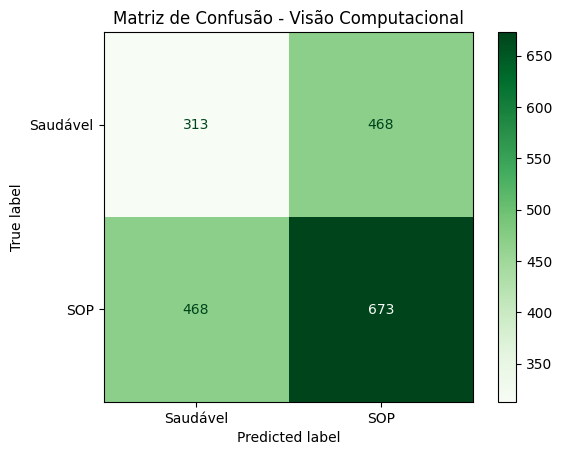

In [30]:
# Pegando as previsões do modelo
Y_pred = model.predict(test_generator)
y_pred = np.where(Y_pred > 0.5, 1, 0)

# Criando a matriz
cm = confusion_matrix(test_generator.classes, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Saudável', 'SOP'])
disp.plot(cmap='Greens')
plt.title('Matriz de Confusão - Visão Computacional')
plt.show()

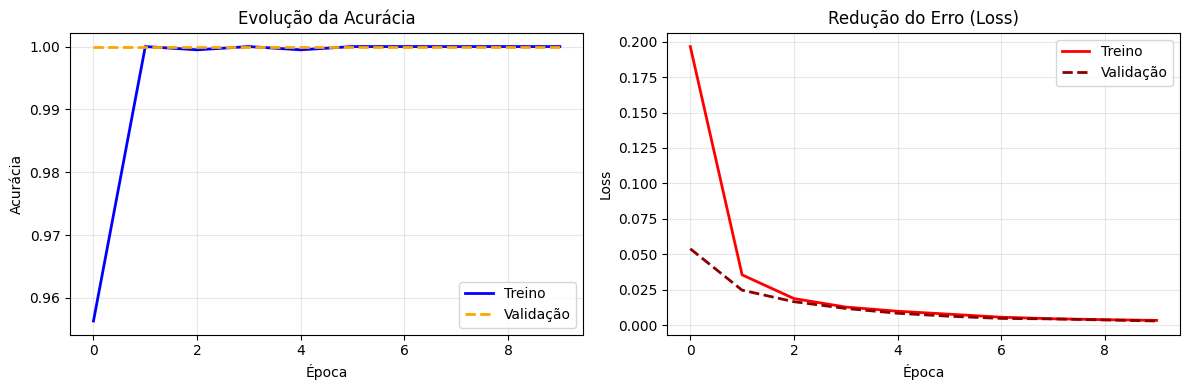

In [33]:

# Criando a figura com dois subplots
plt.figure(figsize=(12, 4))

# Gráfico de Acurácia
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validação', color='orange', linestyle='--', linewidth=2)
plt.title('Evolução da Acurácia')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=0.3)

# Gráfico de Perda (Loss)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino', color='red', linewidth=2)
plt.plot(history.history['val_loss'], label='Validação', color='darkred', linestyle='--', linewidth=2)
plt.title('Redução do Erro (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:


# Gera as predições para o conjunto de teste
Y_pred = model.predict(test_generator)
y_pred = (Y_pred > 0.5).astype(int)

print(classification_report(test_generator.classes, y_pred, target_names=['Sem SOP', 'Com SOP']))

61/61 ━━━━━━━━━━━━━━━━━━━━ 8s 137ms/step
              precision    recall  f1-score   support

     Sem SOP       0.41      0.41      0.41       781
     Com SOP       0.59      0.59      0.59      1141

    accuracy                           0.52      1922
   macro avg       0.50      0.50      0.50      1922
weighted avg       0.52      0.52      0.52      1922



O projeto demonstrou que a Síndrome do Ovário Policístico pode ser identificada de forma multimodal. O Modelo de Dados Clínicos (XGBoost) provou, via SHAP, que o número de folículos é o preditor biológico mais forte para a doença, o que foi validado visualmente na análise de densidade do Pairplot.

No campo da Visão Computacional, o modelo CNN mostrou um potencial de aprendizado altíssimo (atingindo 100% de acurácia no treino), mas enfrentou desafios de generalização no conjunto de teste (acurácia de 52%). Isso reforça a necessidade de bases de imagens médicas mais diversificadas e técnicas de regularização mais agressivas para aplicações clínicas reais.

Em suma, a IA se mostra uma ferramenta poderosa de apoio ao diagnóstico, capaz de filtrar os sintomas mais críticos e auxiliar na interpretação automatizada de exames de imagem